In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from kaggle import api
from pathlib import Path
from shutil import unpack_archive

Setup and download the data

In [2]:
comp = 'bluebook-for-bulldozers'
path = Path('..') / 'data'

In [3]:
if not path.exists():
    path.mkdir(parents=True)
    api.competition_download_cli(comp, path=path)
    unpack_archive(str(path/f'{comp}.zip'), str(path))

In [4]:
[p.name for p in path.iterdir()]

['bluebook-for-bulldozers.zip',
 'Data Dictionary.xlsx',
 'Machine_Appendix.csv',
 'Test.csv',
 'Train.7z',
 'Train.zip',
 'TrainAndValid.7z',
 'TrainAndValid.csv',
 'TrainAndValid.zip',
 'Valid.7z',
 'Valid.csv',
 'Valid.zip',
 'ValidSolution.csv',
 'median_benchmark.csv',
 'random_forest_benchmark_test.csv']

In [5]:
df = pd.read_csv('../data/TrainAndValid.csv', low_memory=False)
df.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000.0,999089,3157,121,3.0,2004,68.0,Low,11/16/2006 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139248,57000.0,117657,77,121,3.0,1996,4640.0,Low,3/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1139249,10000.0,434808,7009,121,3.0,2001,2838.0,High,2/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1139251,38500.0,1026470,332,121,3.0,2001,3486.0,High,5/19/2011 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139253,11000.0,1057373,17311,121,3.0,2007,722.0,Medium,7/23/2009 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.shape

(412698, 53)

In [7]:
df.columns

Index(['SalesID', 'SalePrice', 'MachineID', 'ModelID', 'datasource',
       'auctioneerID', 'YearMade', 'MachineHoursCurrentMeter', 'UsageBand',
       'saledate', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc',
       'fiModelSeries', 'fiModelDescriptor', 'ProductSize',
       'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc',
       'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control',
       'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension',
       'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics',
       'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size',
       'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow',
       'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb',
       'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type',
       'Travel_Controls', 'Differential_Type', 'Steering_Controls'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   object 
 9   saledate                  412698 non-null  object 
 10  fiModelDesc               412698 non-null  object 
 11  fiBaseModel               412698 non-null  object 
 12  fiSecondaryDesc           271971 non-null  object 
 13  fiModelSeries             58667 non-null   o

Most of the columns are string type (object), we should convert them into category datatype

Notice the `saledate` columns, it should be datetime datatype

In [9]:
df.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
saledate                         0
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension     

which columns have more than 90% of missing values?

In [10]:
n = df.shape[0]
[col for col in df.columns if (df[col].isna().sum()/n) > 0.9]

['Blade_Extension',
 'Blade_Width',
 'Enclosure_Type',
 'Engine_Horsepower',
 'Pushblock',
 'Scarifier',
 'Tip_Control']

A lot of missing values

In [11]:
df.describe()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter
count,4.126980e+05,412698.000000,4.126980e+05,412698.000000,412698.000000,392562.000000,412698.000000,1.475040e+05
mean,2.011161e+06,31215.181414,1.230061e+06,6947.201828,135.169361,6.585268,1899.049637,3.522988e+03
std,1.080068e+06,23141.743695,4.539533e+05,6280.824982,9.646749,17.158409,292.190243,2.716993e+04
min,1.139246e+06,4750.000000,0.000000e+00,28.000000,121.000000,0.000000,1000.000000,0.000000e+00
25%,1.421898e+06,14500.000000,1.088593e+06,3261.000000,132.000000,1.000000,1985.000000,0.000000e+00
50%,1.645852e+06,24000.000000,1.284397e+06,4605.000000,132.000000,2.000000,1995.000000,0.000000e+00
75%,2.261012e+06,40000.000000,1.478079e+06,8899.000000,136.000000,4.000000,2001.000000,3.209000e+03
max,6.333349e+06,142000.000000,2.486330e+06,37198.000000,173.000000,99.000000,2014.000000,2.483300e+06


In [36]:
df.select_dtypes(include='number').isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
dtype: int64

In [37]:
median_hours = df['MachineHoursCurrentMeter'].median()
df['MachineHoursCurrentMeter'] = df['MachineHoursCurrentMeter'].fillna(median_hours)
df['MachineHoursCurrentMeter'].isna().sum()

np.int64(0)

The distribution of `SalePrice` column. Is it skewed? Are there outliers?

<Axes: xlabel='SalePrice', ylabel='Count'>

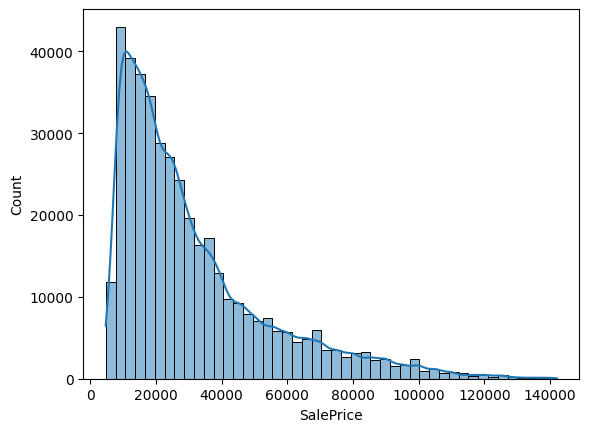

In [12]:
sns.histplot(df['SalePrice'], kde=True, binwidth=3000)

The `SalePrice` distribution is right skewed, this make sense because bulldozers lose value over time: once a machine hit the auction block after several years of use its price typically fall far below its original price, only small fraction of the dataset represents nearly new or well maintained machines with low hours, so those high values pull the mean upward creating a long right tail

in this competition the evaluation metric is RMSLE(root mean squared log error), the best practices is to apply the log transform to the `SalePrice'

In [13]:
df['SalePrice'] = np.log(df['SalePrice'])

<Axes: xlabel='SalePrice', ylabel='Count'>

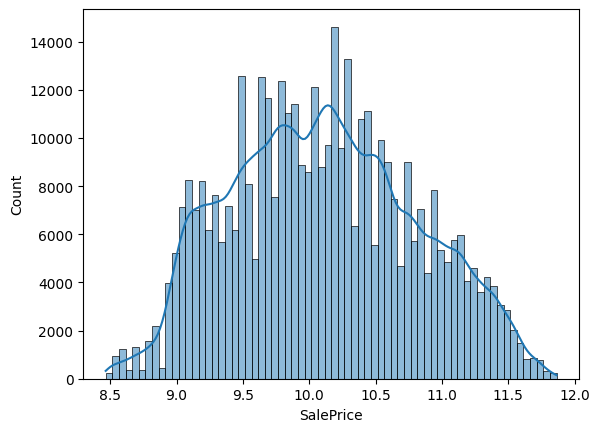

In [14]:
sns.histplot(df['SalePrice'], kde=True, binwidth=0.05)

it's looking good now

### Explore Categorical features

In [15]:
cats = df.select_dtypes(include=['object']).columns
cats

Index(['UsageBand', 'saledate', 'fiModelDesc', 'fiBaseModel',
       'fiSecondaryDesc', 'fiModelSeries', 'fiModelDescriptor', 'ProductSize',
       'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc',
       'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control',
       'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension',
       'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics',
       'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size',
       'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow',
       'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb',
       'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type',
       'Travel_Controls', 'Differential_Type', 'Steering_Controls'],
      dtype='object')

In [16]:
df[cats].nunique()

UsageBand                     3
saledate                   4013
fiModelDesc                5059
fiBaseModel                1961
fiSecondaryDesc             177
fiModelSeries               123
fiModelDescriptor           140
ProductSize                   6
fiProductClassDesc           74
state                        53
ProductGroup                  6
ProductGroupDesc              6
Drive_System                  4
Enclosure                     6
Forks                         2
Pad_Type                      4
Ride_Control                  3
Stick                         2
Transmission                  8
Turbocharged                  2
Blade_Extension               2
Blade_Width                   6
Enclosure_Type                3
Engine_Horsepower             2
Hydraulics                   12
Pushblock                     2
Ripper                        4
Scarifier                     2
Tip_Control                   3
Tire_Size                    17
Coupler                       3
Coupler_

there are several columns have really high number of unique values(high cardinality) such as `fiModeDesc`, `fiBaseModel`, ... or some have low number of unique value is `Stick`, `Fork`, `UsageBand`, `ProductGroup`, ...

what is the frequency distribution of some of the key categorical columns

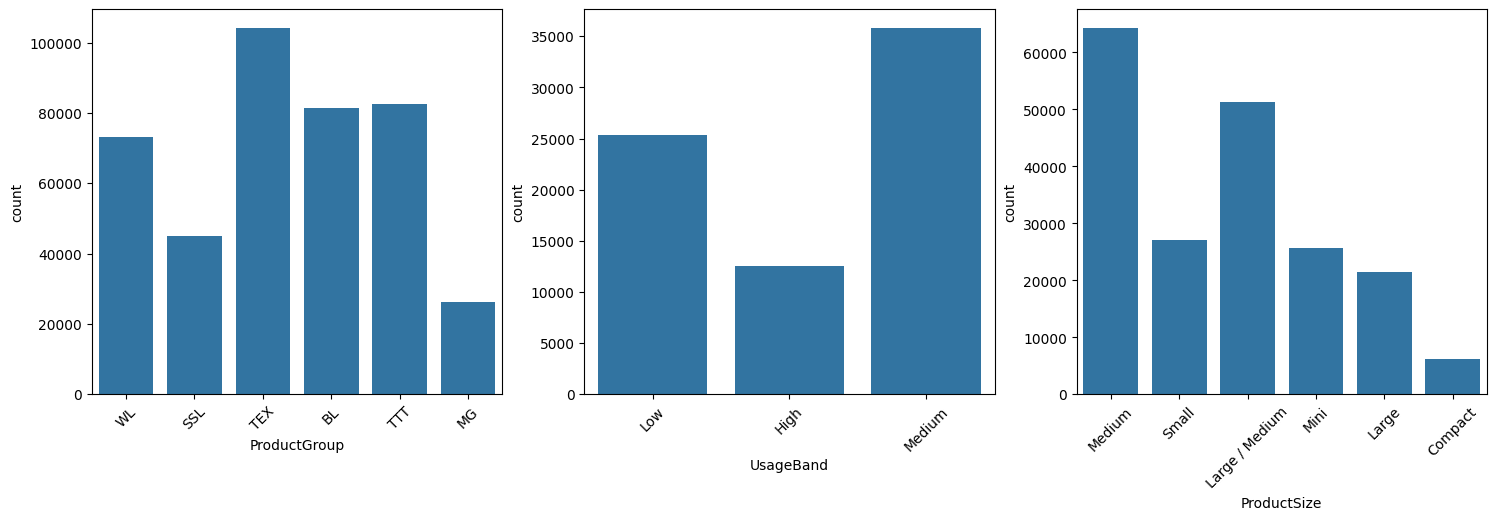

In [17]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
cols = ['ProductGroup', 'UsageBand', 'ProductSize']
for i, col in enumerate(cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].tick_params(axis='x', rotation=45)
plt.show()

- ProductGroup:

  - Most common: TEX (Track Excavators) is the most frequent product group, with over 100,000 units.
  - Least common: MG (Motor Graders) is the least frequent, with around 25,000-30,000 units.
  - Other groups like WL (Wheel Loader), BL (Backhoe Loader), and TTT (Track Type Tractor) have significant counts as well.
- UsageBand:

  - Most common: Medium usage is the most reported, with over 35,000 entries.
  - Least common: High usage is the least reported, around 12,500 entries.
  - Low usage is in between.
- ProductSize:

  - Most common: Medium is the most frequent product size, with over 60,000 units.
  - Least common: Compact is the least frequent, with less than 10,000 units.
  - Small, Large / Medium, Mini, and Large fall in between, with Large / Medium being the second most common.

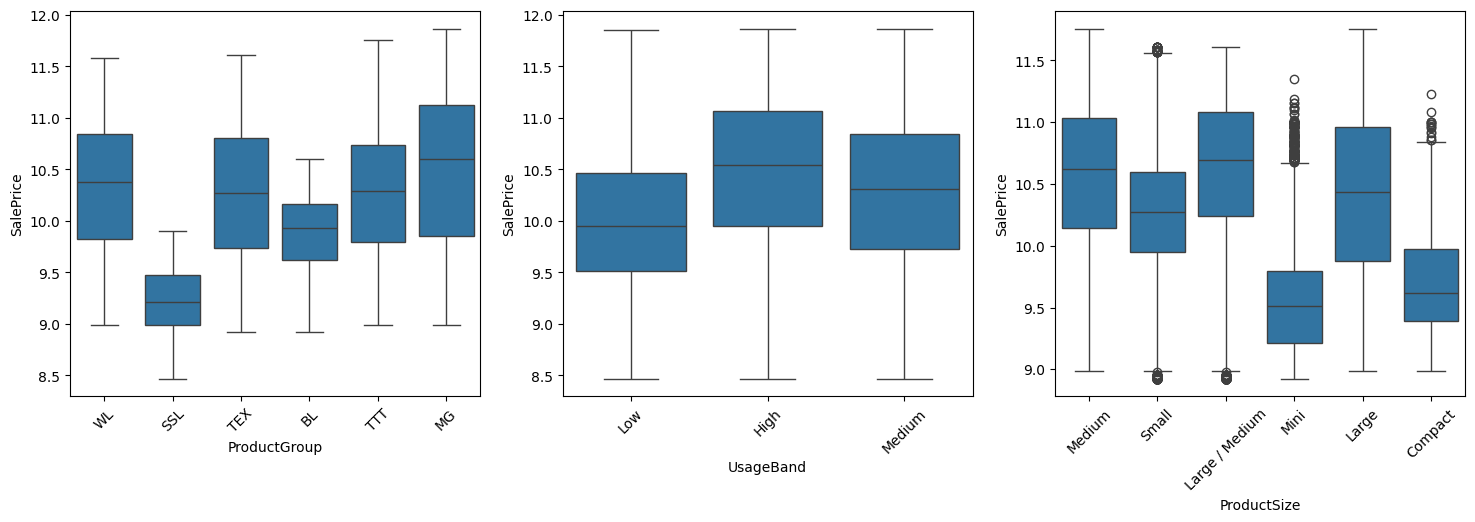

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cols):
    sns.boxplot(data=df, x=col, y='SalePrice', ax=axes[i])
    axes[i].tick_params(axis='x', rotation=45)
plt.show()

- ProductGroup vs. SalePrice: The median SalePrice varies significantly across different product groups. The spread of prices also differs.

- UsageBand vs. SalePrice: there's a noticeable trend. One might intially thin  higher usage means more wear and tear, leading to lower prices. However, i could also mean these are more capable, in-demand machines, or perhaps the `UsageBand` reflect recent, active use before sale.

- ProductSize vs. SalePrice: there's a very clear relationship

So the order of `UsageBand` and `ProductSize` does matter here so let's convert them to categorical datatype with relevant order

In [19]:
sizes = 'Large','Large / Medium','Medium','Small','Mini','Compact'
df['ProductSize'] = df['ProductSize'].astype('category')
df['ProductSize'].cat.set_categories(sizes, ordered=True)

0            NaN
1         Medium
2            NaN
3          Small
4            NaN
           ...  
412693      Mini
412694      Mini
412695      Mini
412696      Mini
412697      Mini
Name: ProductSize, Length: 412698, dtype: category
Categories (6, object): ['Large' < 'Large / Medium' < 'Medium' < 'Small' < 'Mini' < 'Compact']

In [20]:
bands = ['Low', 'Medium', 'High']
df['UsageBand'] = df['UsageBand'].astype('category').cat.set_categories(bands, ordered=True)

### Explore numerical features

Exclude those ID columns for now as they are identifiers rather than direct numerical measures for modeling `SalePrice`

In [21]:
exclude =['SalesID', 'SalePrice', 'MachineID', 'ModelID', 'auctioneerID']
num_cols = df.drop(exclude, axis=1).select_dtypes(include='number').columns.to_list()
num_cols

['datasource', 'YearMade', 'MachineHoursCurrentMeter']

In [22]:
df[num_cols].describe()

,datasource,YearMade,MachineHoursCurrentMeter
count,412698.000000,412698.000000,1.475040e+05
mean,135.169361,1899.049637,3.522988e+03
std,9.646749,292.190243,2.716993e+04
min,121.000000,1000.000000,0.000000e+00
25%,132.000000,1985.000000,0.000000e+00
50%,132.000000,1995.000000,0.000000e+00
75%,136.000000,2001.000000,3.209000e+03
max,173.000000,2014.000000,2.483300e+06


`MachineHoursCurrentMeter`: Notice that `min`, `q1`, `q2` are all 0, is indeed significant, this means that at least half of the machines in the data set for which this value is recorded have 0 machine hour. this could mean that many machines are new or have genuinely not been used

<Axes: xlabel='MachineHoursCurrentMeter', ylabel='Count'>

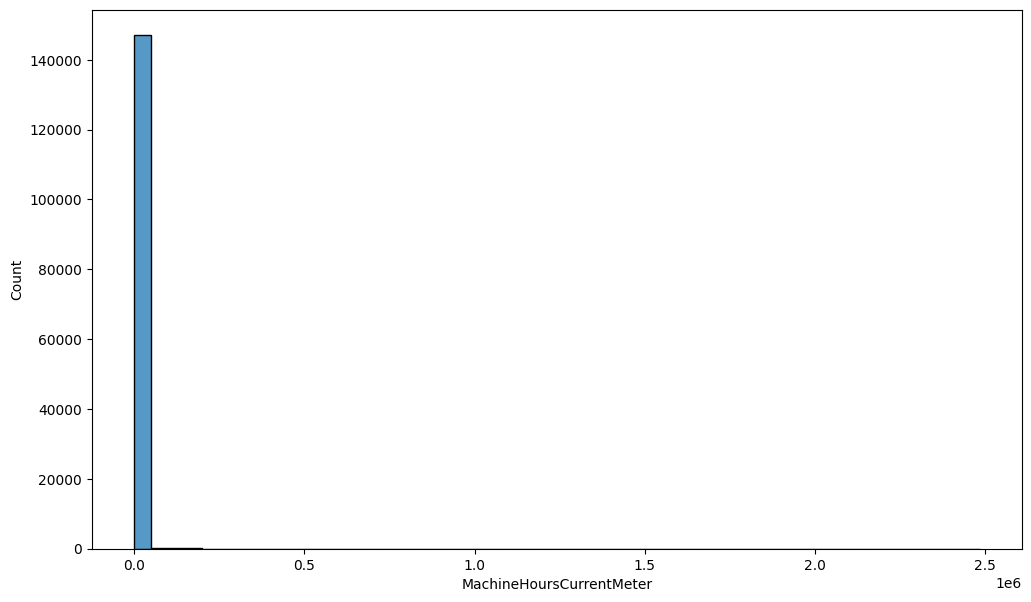

In [23]:
plt.figure(figsize=(12, 7))
sns.histplot(df['MachineHoursCurrentMeter'], kde=False, bins=50) # dropna() just in case of NaNs

Because most of the machine have 0 recorded hours, so it's really hard to see the distribution of the plot, so let's exclude those 0 hour machine and apply the log for the others to see the distribution

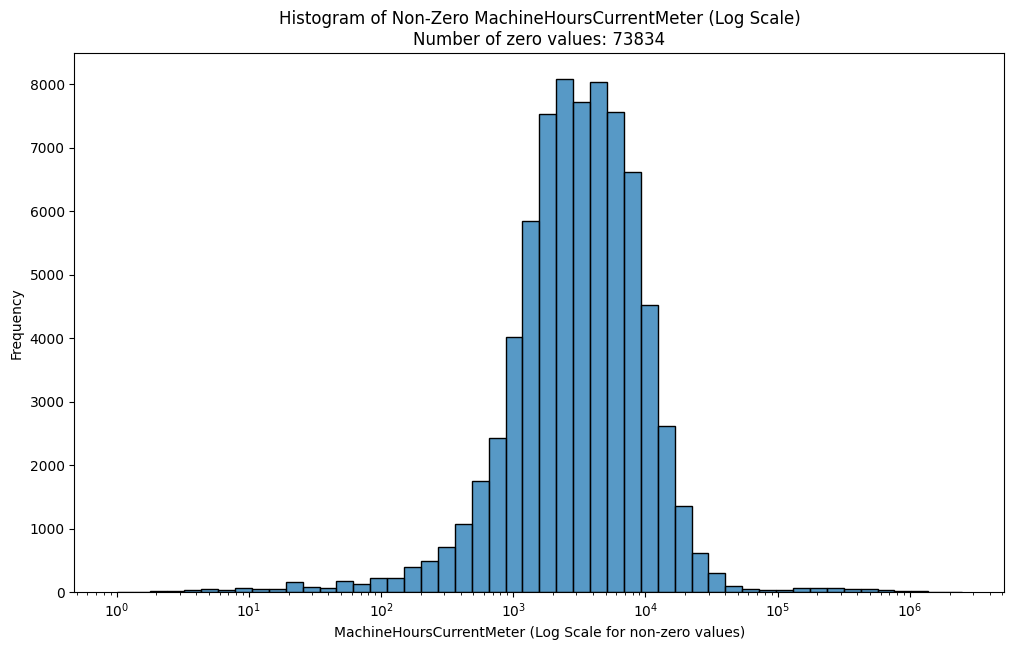

In [24]:
non_zero_hours = df[df['MachineHoursCurrentMeter'] > 0]['MachineHoursCurrentMeter']
num_zeros = df[df['MachineHoursCurrentMeter'] == 0]['MachineHoursCurrentMeter'].count()

plt.figure(figsize=(12, 7))
sns.histplot(non_zero_hours, kde=False, bins=50, log_scale=True) # log_scale on x-axis
plt.title(f'Histogram of Non-Zero MachineHoursCurrentMeter (Log Scale)\nNumber of zero values: {num_zeros}')

plt.xlabel('MachineHoursCurrentMeter (Log Scale for non-zero values)')
plt.ylabel('Frequency')
plt.show()

<Axes: xlabel='MachineHoursCurrentMeter', ylabel='Count'>

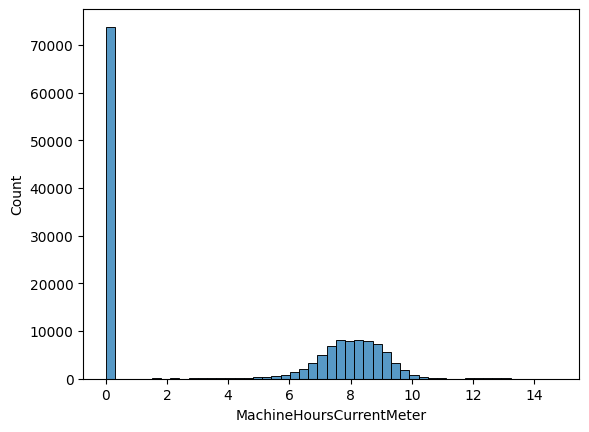

In [25]:
hour_log = np.log(df['MachineHoursCurrentMeter'] + 1)
sns.histplot(hour_log, kde=False)

`YearMade`: Interestingly we have min of `YearMade` is 1000 this is highly unlikely to be a correct manufacturing year for a bulldozer sold in recent times, it probably a placeholder for missing/unknown years, we will need to addressed this later 

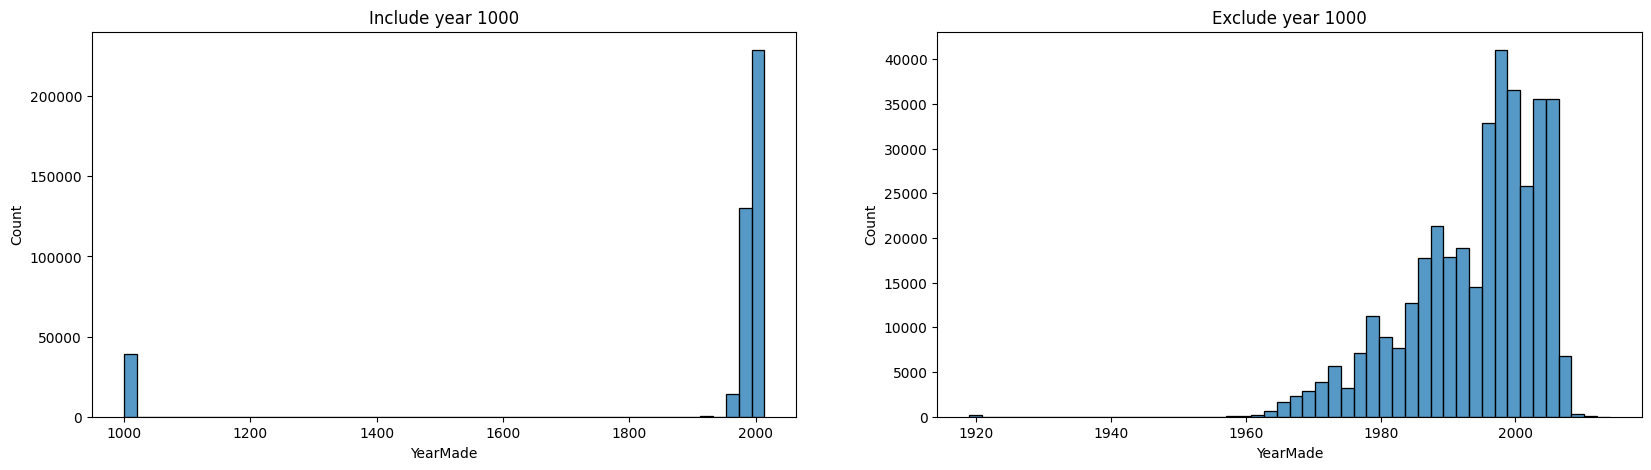

In [26]:
fig, axe = plt.subplots(1, 2, figsize=(20, 5))
sns.histplot(df['YearMade'], kde=False, bins=50, ax=axe[0])
axe[0].set_title('Include year 1000')
exclude_1000 = df[df['YearMade'] > 1000]['YearMade']
sns.histplot(exclude_1000, kde=False, bins=50, ax=axe[1])
axe[1].set_title('Exclude year 1000')
plt.show()

we have the max value of `YearMade` is 2014 which is weird because first of all the competition is run on 2013, and the description of the data said the final sale date on Test set is November 2012 so let's take a look at those records with `YearMade` after 2012 

In [27]:
df[df['YearMade'].isin([2012, 2013, 2014])]

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
295706,2226857,10.463103,40066,4125,136,1.0,2012,4534.0,Low,5/6/2010 0:00,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,Straight,None or Unspecified,NaN,NaN
395524,6275685,10.915088,156521,1453,149,1.0,2013,NaN,NaN,12/7/2011 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
409039,6282827,10.404263,1927533,1931,149,2.0,2014,NaN,NaN,1/28/2012 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
410474,6294577,10.434116,1845767,11742,149,0.0,2014,NaN,NaN,3/22/2012 0:00,...,None or Unspecified,None or Unspecified,Manual,None or Unspecified,Triple,NaN,NaN,NaN,NaN,NaN


Let's dig deeper on this by convert `saledate` into datetime and then subset rows where `YearMade` is larger than `saledate` year

In [28]:
df['saledate'] = pd.to_datetime(df['saledate'])
idx = df['YearMade'] > df['saledate'].dt.year
df[idx]

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
27786,1256766,10.203592,1424836,3247,132,2.0,1997,NaN,NaN,1996-12-13,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
81843,1380049,10.275051,1189094,3538,132,1.0,2000,NaN,NaN,1999-10-14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
161311,1582210,11.002100,1482307,28842,132,1.0,2006,NaN,NaN,2005-02-15,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
176543,1607397,11.184421,1104056,4753,132,11.0,1998,NaN,NaN,1997-05-29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
206920,1656135,10.184900,1229496,8559,132,1.0,1998,NaN,NaN,1996-02-21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
209191,1662009,9.047821,1481256,14755,132,2.0,2008,NaN,NaN,2001-10-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
213253,1672382,9.392662,1151751,4988,132,4.0,2008,NaN,NaN,1996-02-08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
231762,1725834,10.021271,1106818,8954,132,1.0,2006,NaN,NaN,1996-07-16,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
242681,1748962,10.203592,1361981,257,132,6.0,2008,NaN,NaN,1997-12-15,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,Straight,None or Unspecified,NaN,NaN
251546,1766755,11.512925,1241578,457,132,6.0,2002,NaN,NaN,1995-08-11,...,None or Unspecified,"10' 6""",None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN


15 records, so the question is, is it really a data entry error, or the fact that sale a product before it were made is possible in auction, i think it's the data entry error, but i'm not an expert at auction stuff, so i asks GPT this, and it turns out that these auctions are typically for existing, physical machines. the context is largely the used equipment market, some of the the record above even shown the `YearMade` values that are significantly later than `saledate` (e.g., `YearMade` 2008, `saledate` 2001, `YearMade` 2008, `saledate` 1996)

alright we could drop those error rows or set them equal to the `saledate`'s year

In [29]:
df.loc[idx, 'YearMade'] = df.loc[idx, 'saledate'].dt.year

<Axes: xlabel='YearMade', ylabel='SalePrice'>

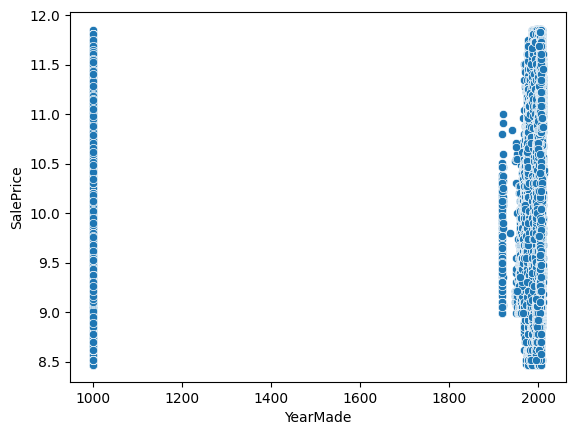

In [30]:
sns.scatterplot(x=df['YearMade'], y=df['SalePrice'])

we should exclude those machine with YearMade = 1000 for now for better visualization of the relationship between `SalePrice` and `YearMade`

<Axes: xlabel='YearMade', ylabel='SalePrice'>

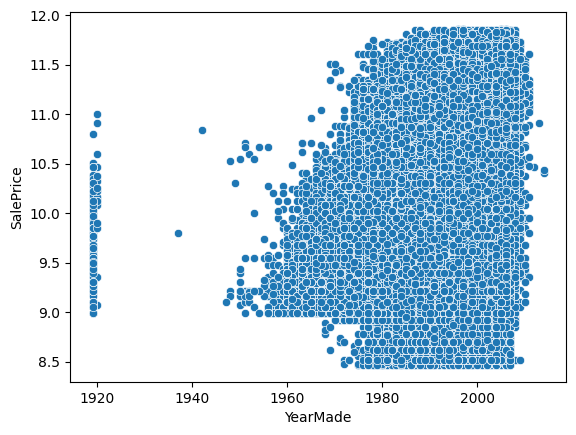

In [31]:
sns.scatterplot(x=exclude_1000, y=df['SalePrice'])

There's a clear trend as `YearMade` increases(the machine is newer) the `SalePrice` tends to be higher, this is intuitive. The spread of `SalePrice` appears to increase for newer machines. There's a vertical cluster of points around `YearMade` = 1920. This might indicate that `1920` is used as default or placeholder for very old machines where the exact year is unknown. similar to how 1000 was used, this is probably due to the data set was merged from multiple sources

The old machines generally have lower sale prices

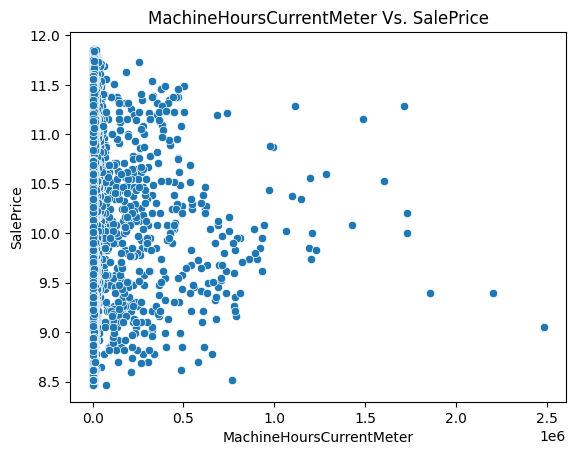

In [32]:
sns.scatterplot(x=df['MachineHoursCurrentMeter'], y=df['SalePrice'])
plt.title("MachineHoursCurrentMeter Vs. SalePrice")
plt.show()

because of the skewness and lot of 0 hours, it's really hard to read the plot, let's consider log transform

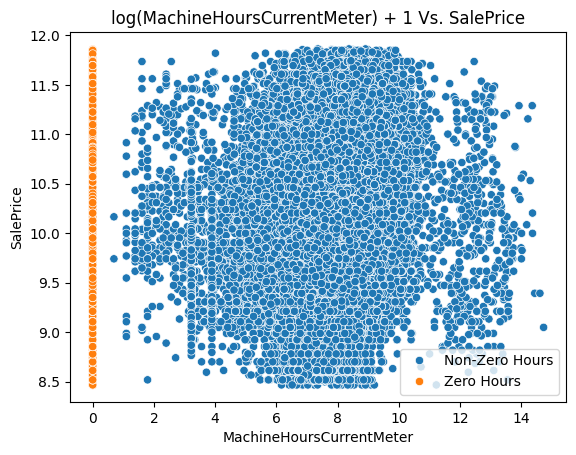

In [33]:
sns.scatterplot(x=np.log(df['MachineHoursCurrentMeter'] + 1), y=df['SalePrice'],
                hue=np.where(df['MachineHoursCurrentMeter'] == 0, 'Zero Hours', 'Non-Zero Hours'))
plt.title("log(MachineHoursCurrentMeter) + 1 Vs. SalePrice")
plt.show()

Machines with zero recorded hours's show a very wide range of `SalePrices` values, This is a key observation. It suggests that "zero hours" doesn't uniformly mean "brand new and expensive" or "cheap". It could mean the machine is actually new, the hour was not recorded(effectively missing data). The `SalePrice` for these machines likely depends on other factors `YearMade`, `ProductGroup`, etc.

With non-zero hours(blue dots) there appears to be a slight negative trend as `MachineHoursCurrentMeter` increases, `SalePrice` tends to decrease, however the relationship is not quite strong, a lot of variance, this means that while hours have some influence, they are not the sole or strongest driver of price for machines with recorded usage, 

While some numerical features like `YearMade` show a general trend with `SalePrice` the relationship is not strictly linear, and there's a lot of variance, therefore Tree-based models like RandomForests, Gradient Boosting machines XGBoost, ... are popular for those datasets like this, because it can capture more complex pattern, we'll discuss about this more later

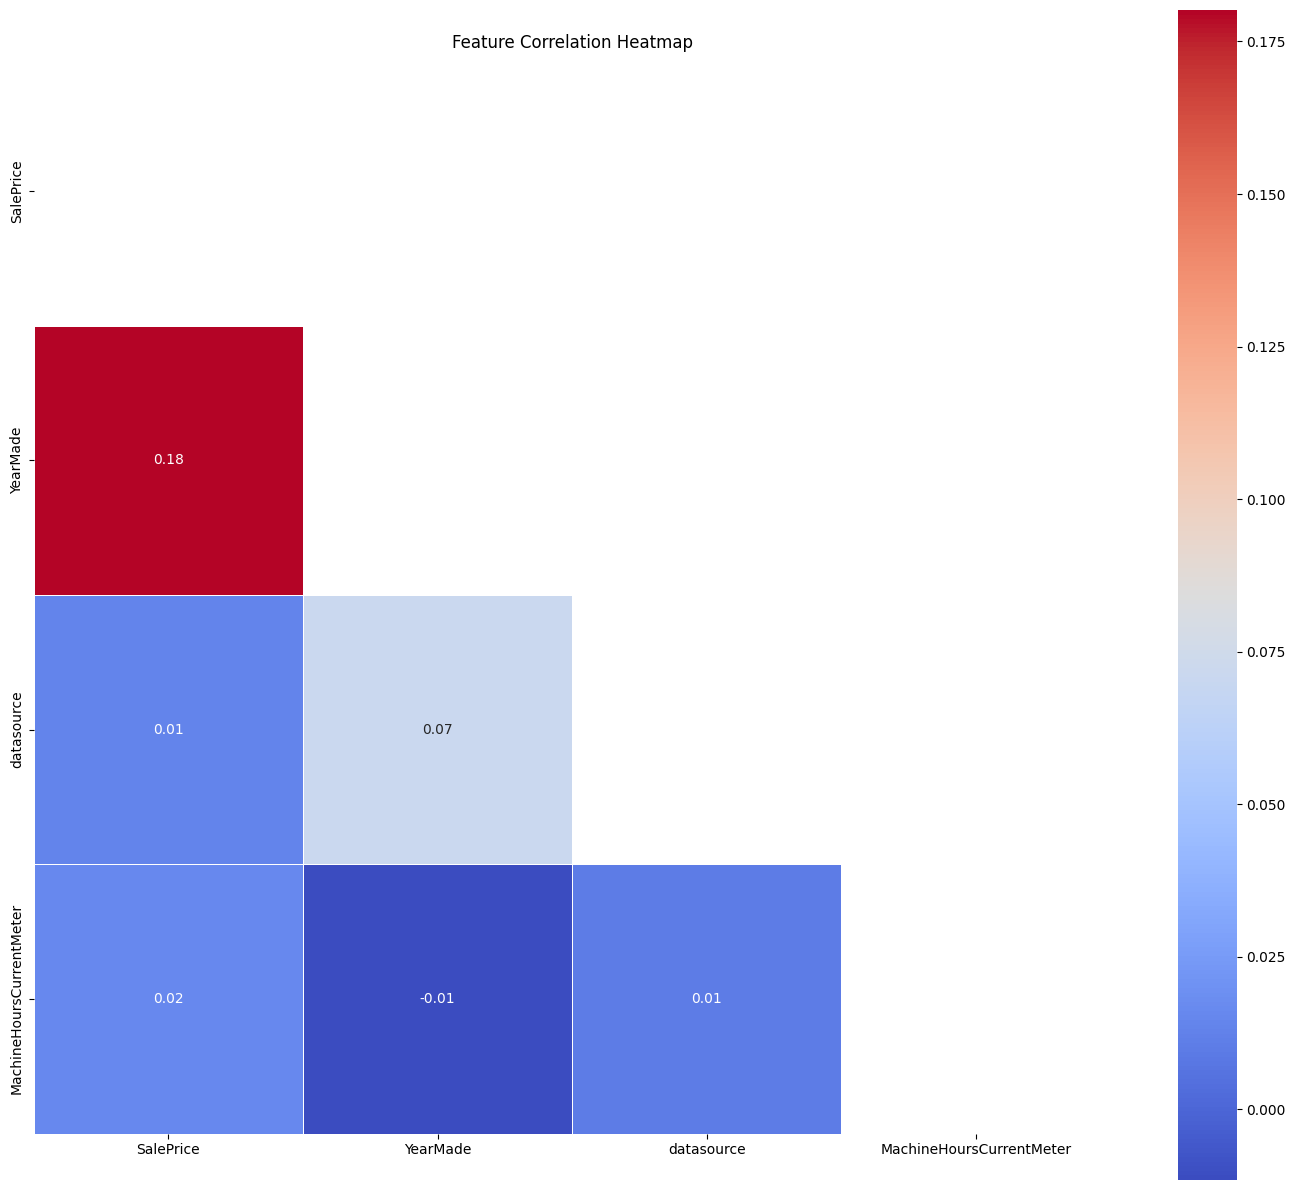

In [34]:
plt.figure(figsize=(14, 12))
corr = df[['SalePrice', 'YearMade', 'datasource', 'MachineHoursCurrentMeter']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths='.5')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Preprocessing

### Dealing with TimeSeries Data(`saledate`)

To help our algorithm handle dates intelligently we would like our model to know more than just whether a date is more recent or less recent than others, we might want our model to make decision based on that date's day of the week, on whether a day is holiday, on what month it is in, and so forth. To accomplish this we replace every date columns with a set of date metadata columns such as holiday, day of week, and month. These columns will in form of categorical datatype, and hopefully it will be useful to our model

In [35]:
def add_date_metadata(df):
    pass